   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.3 MB/s eta 0:00:00
TOPOLOGICAL SPECTRAL HOMEOSTASIS MODEL v2.1
[PDB] Downloading 1U3C ...
[PDB] Downloading 1U7C ...

[STRUCTURES]
Target  1U3C: chain A, 485 Cα residues
Control 1U7C: chain A, 372 Cα residues

[GRAPH]
Native graph      : N=485, E=1917
Randomized graph  : N=485, E=1917
Degree sequence preserved exactly: True

FOUR-STATE FACTORIAL RESULTS
State 00 | 00 Intact                | gamma_eff = 0.26355172
State 10 | 10 Protein ablated       | gamma_eff = 0.41409509
State 01 | 01 Microbiome ablated    | gamma_eff = 0.65471067
State 11 | 11 Double ablation       | gamma_eff = 0.87077734

[INTERACTION EFFECT]
Delta_int = gamma11 - gamma10 - gamma01 + gamma00
Delta_int = 0.87077734 - 0.41409509 - 0.65471067 + 0.26355172
Delta_int = 0.06552329

[INDEPENDENT INTEGRAL CHECK]
Delta_int from direct integral = 0.06552329
Numerical agreement = True

RESULT: Delta_int > 0 -> super-additive interaction observed.

SPECTRAL CONVERGENCE

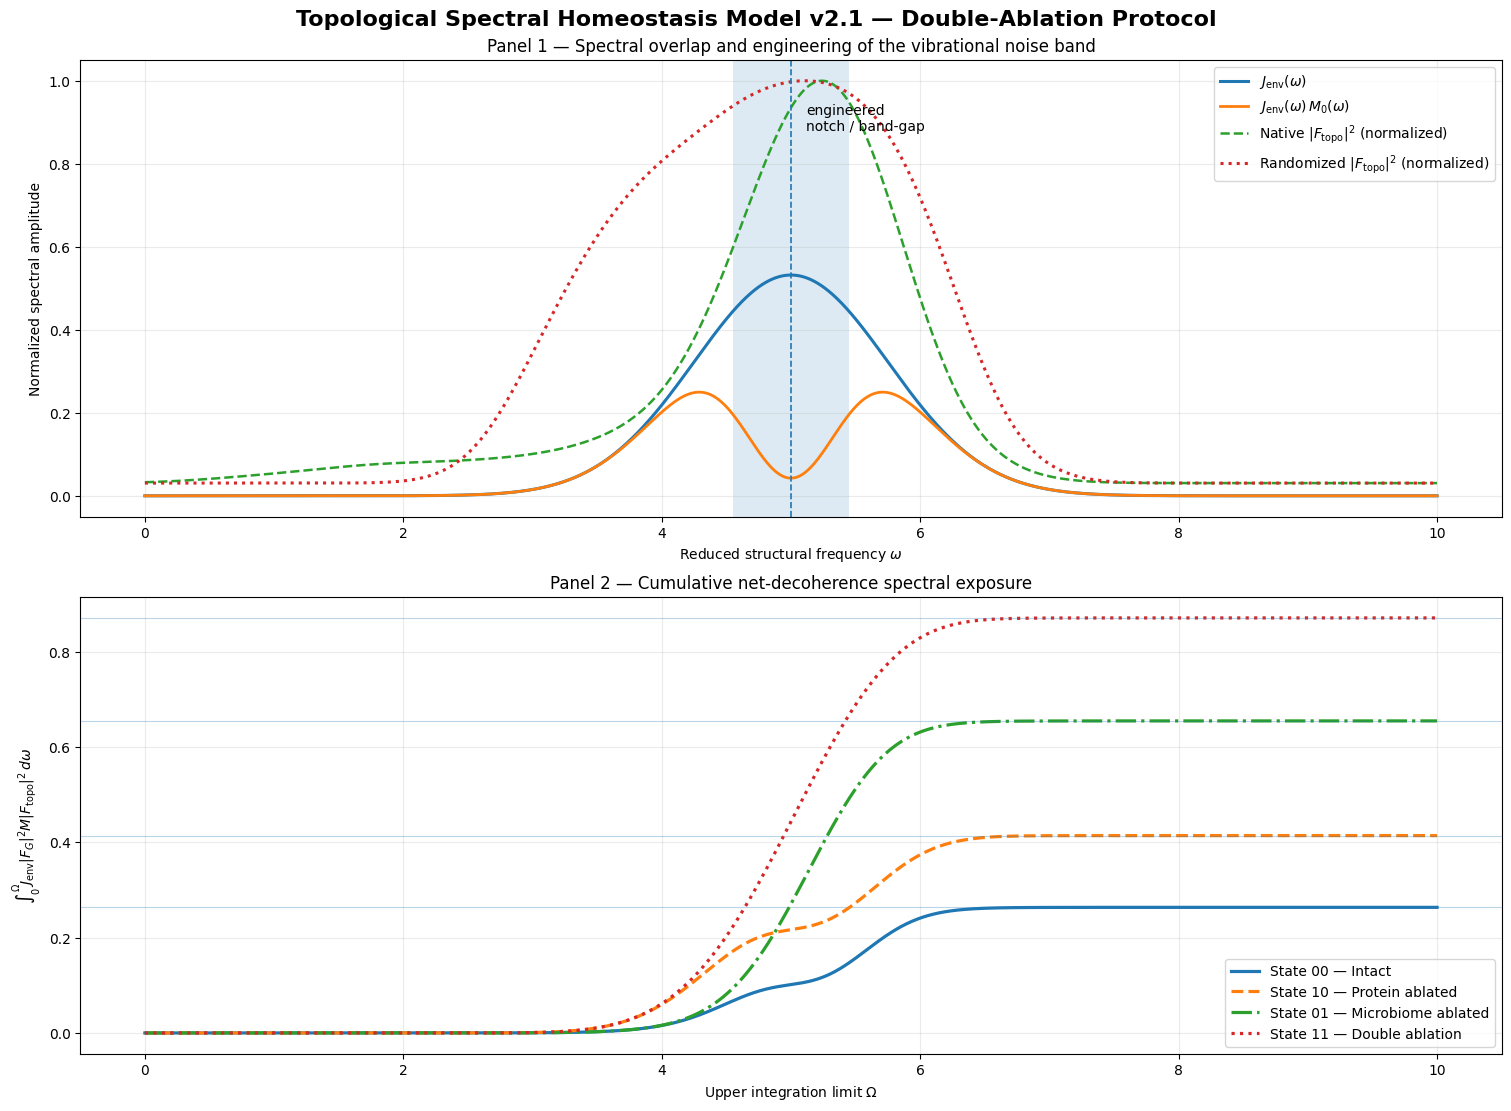


OUTPUTS
Plot : tsh_v21_outputs/TSH_v21_double_ablation.png
CSV  : tsh_v21_outputs/TSH_v21_results.csv

Done.


In [1]:
# ============================================================
# TOPOLOGICAL SPECTRAL HOMEOSTASIS MODEL v2.1
# Double-Ablation Protocol on real PDB coordinates
#
# Target  : Arabidopsis thaliana Cryptochrome-1 PHR, 1U3C
# Control : E. coli AmtB, 1U7C
#
# Core model:
# gamma_eff = ∫ W(ω) J_env(ω) |F_G(ω)|^2
#                  M(ω) |F_topo(ω)|^2 dω
#
# IMPORTANT:
# - Uses real Cα coordinates parsed from the PDB structures.
# - GNM contact network threshold = 7.0 Å.
# - Randomization is degree-preserving and deterministic.
# - Structural spectral density is smoothed with Silverman's rule.
# - Grounding is held fixed across the four factorial states so that
#   the causal interaction isolates topology × microbiome.
# - The sign of Delta_int is measured, never hard-coded.
# ============================================================


# ------------------------------------------------------------
# 0. Colab dependencies
# ------------------------------------------------------------
!pip -q install biopython networkx scipy pandas matplotlib


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------
from pathlib import Path
import urllib.request
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa


# ------------------------------------------------------------
# 2. Global configuration
# ------------------------------------------------------------
SEED = 20260920

TARGET_PDB = "1U3C"
CONTROL_PDB = "1U7C"

# Preferred chains; if absent, the script falls back to the
# longest standard-protein chain.
PREFERRED_CHAIN = {
    TARGET_PDB: "A",
    CONTROL_PDB: "A",
}

# GNM contact threshold
CUTOFF_ANGSTROM = 7.0

# Reduced structural-frequency coordinate.
# This is NOT a literal spectroscopic frequency in rad/s.
# It is a dimensionless spectral coordinate calibrated so that
# the target native median structural mode is mapped near omega=5.
OMEGA_MIN = 0.0
OMEGA_MAX = 10.0
N_OMEGA = 4000

NOISE_CENTER = 5.0
NOISE_SIGMA = 0.75

# Microbiome notch M0:
# strong suppression centered at omega=5.
NOTCH_DEPTH = 0.92
NOTCH_SIGMA = 0.45

# Topological amplitude map:
# F_topo = baseline + gain * normalized KDE density
TOPO_BASELINE = 0.35
TOPO_GAIN = 1.65

# Grounded electrostatic boundary amplitude.
# Since |F_G|^2 enters gamma, grounding contributes 0.5^2 = 0.25.
FG_GROUNDED = 0.5
FG_UNGROUNDED = 1.0

# Degree-preserving graph randomization
NSWAP_FACTOR = 2.0
MAX_RANDOMIZATION_ATTEMPTS = 30

OUTPUT_DIR = Path("tsh_v21_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 3. PDB download
# ------------------------------------------------------------
def download_pdb(pdb_id: str, output_dir: Path) -> Path:
    """
    Download a PDB coordinate file directly from the RCSB file endpoint.
    This is a raw coordinate-file download, not a PDB API query.
    """
    pdb_id = pdb_id.upper()
    path = output_dir / f"{pdb_id}.pdb"

    if path.exists() and path.stat().st_size > 500:
        return path

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

    print(f"[PDB] Downloading {pdb_id} ...")
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as exc:
        raise RuntimeError(
            f"Could not download {pdb_id}. "
            f"Check Colab internet access. Original error: {exc}"
        ) from exc

    if not path.exists() or path.stat().st_size < 500:
        raise RuntimeError(f"Downloaded PDB file for {pdb_id} is missing or invalid.")

    text = path.read_text(errors="ignore")
    if "ATOM" not in text:
        raise RuntimeError(f"{pdb_id}.pdb does not appear to contain atomic coordinates.")

    return path


# ------------------------------------------------------------
# 4. Extract one standard-protein chain using Cα coordinates
# ------------------------------------------------------------
def extract_ca_coordinates(
    pdb_path: Path,
    preferred_chain: str | None = None,
):
    """
    Select a protein chain and return:
      - residue labels
      - Cα coordinates in Å
      - selected chain ID
    """
    parser = PDBParser(QUIET=True)

    structure = parser.get_structure(pdb_path.stem, str(pdb_path))
    model = next(structure.get_models())

    chain_candidates = []

    for chain in model:
        residues = []

        for residue in chain.get_residues():
            if not is_aa(residue, standard=True):
                continue
            if "CA" not in residue:
                continue

            ca = residue["CA"]

            # Prefer the currently selected conformer if disordered.
            if ca.is_disordered():
                try:
                    ca = ca.disordered_get()
                except Exception:
                    continue

            residues.append(residue)

        if len(residues) >= 30:
            chain_candidates.append((chain.id, residues))

    if not chain_candidates:
        raise RuntimeError(
            f"No suitable standard-protein chain found in {pdb_path.name}."
        )

    # Prefer requested chain if available.
    selected = None

    if preferred_chain is not None:
        for chain_id, residues in chain_candidates:
            if chain_id == preferred_chain:
                selected = (chain_id, residues)
                break

    # Otherwise use longest protein chain.
    if selected is None:
        selected = max(chain_candidates, key=lambda x: len(x[1]))

    chain_id, residues = selected

    labels = []
    coords = []

    for residue in residues:
        ca = residue["CA"]

        labels.append(
            f"{chain_id}:{residue.get_resname()}:{residue.id[1]}{residue.id[2].strip()}"
        )
        coords.append(ca.coord.astype(float))

    coords = np.asarray(coords, dtype=float)

    if coords.shape[0] < 30:
        raise RuntimeError("Too few residues for a meaningful GNM analysis.")

    return labels, coords, chain_id


# ------------------------------------------------------------
# 5. Build a residue contact graph
# ------------------------------------------------------------
def build_contact_graph(coords: np.ndarray, cutoff: float = 7.0):
    """
    Binary Cα-contact graph:
        W_ij = 1 if ||r_i-r_j|| <= cutoff
              0 otherwise

    Diagonal is zero.
    """
    dist = cdist(coords, coords)

    adjacency = (dist <= cutoff).astype(float)
    np.fill_diagonal(adjacency, 0.0)

    adjacency = np.maximum(adjacency, adjacency.T)

    graph = nx.from_numpy_array(adjacency)

    return adjacency, graph, dist


# ------------------------------------------------------------
# 6. Graph Laplacian
# ------------------------------------------------------------
def graph_laplacian(adjacency: np.ndarray):
    """
    L = D - W
    """
    degrees = adjacency.sum(axis=1)
    D = np.diag(degrees)
    L = D - adjacency

    # Numerical symmetry guard.
    L = 0.5 * (L + L.T)

    return L


# ------------------------------------------------------------
# 7. Ensure native contact graph is suitable
# ------------------------------------------------------------
def largest_connected_component_graph(graph: nx.Graph):
    """
    Fallback only if a coordinate-derived graph is disconnected.
    """
    if nx.is_connected(graph):
        return graph

    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    giant_nodes = components[0]

    warnings.warn(
        f"Contact graph was disconnected. "
        f"Using largest connected component with {len(giant_nodes)} nodes."
    )

    return graph.subgraph(sorted(giant_nodes)).copy()


# ------------------------------------------------------------
# 8. Degree-preserving randomization
# ------------------------------------------------------------
def degree_preserving_randomization(
    graph: nx.Graph,
    seed: int,
    nswap_factor: float = 2.0,
    max_attempts: int = 30,
):
    """
    Randomize edges using double-edge swaps.

    Preserves the exact degree sequence while disrupting
    sequence/geometric contact organization.

    We retry until the randomized graph is connected and
    the degree sequence is exactly preserved.
    """
    if not nx.is_connected(graph):
        graph = largest_connected_component_graph(graph)

    original_degrees = sorted(dict(graph.degree()).values())
    edge_count = graph.number_of_edges()

    if edge_count < 3:
        raise RuntimeError("Graph has too few edges for degree-preserving randomization.")

    rng = np.random.default_rng(seed)

    nswap = max(1, int(nswap_factor * edge_count))
    max_tries = max(100, 25 * nswap)

    for attempt in range(max_attempts):
        randomized = graph.copy()

        trial_seed = int(rng.integers(0, 2**32 - 1))

        try:
            nx.double_edge_swap(
                randomized,
                nswap=nswap,
                max_tries=max_tries,
                seed=trial_seed,
            )
        except Exception:
            continue

        new_degrees = sorted(dict(randomized.degree()).values())

        if new_degrees != original_degrees:
            continue

        if not nx.is_connected(randomized):
            continue

        return randomized

    raise RuntimeError(
        "Could not obtain a connected degree-preserving randomized graph "
        f"after {max_attempts} attempts."
    )


# ------------------------------------------------------------
# 9. Laplacian eigenvalues
# ------------------------------------------------------------
def positive_laplacian_eigenvalues(graph: nx.Graph):
    """
    Returns non-zero eigenvalues of L = D-W.
    """
    adjacency = nx.to_numpy_array(graph, dtype=float)
    L = graph_laplacian(adjacency)

    eigvals = np.linalg.eigvalsh(L)

    # Remove numerical zero modes.
    positive = eigvals[eigvals > 1e-8]

    if len(positive) < 5:
        raise RuntimeError("Too few non-zero Laplacian eigenvalues.")

    return positive


# ------------------------------------------------------------
# 10. Structural frequency mapping
# ------------------------------------------------------------
def eigenvalues_to_omega(
    eigenvalues: np.ndarray,
    lambda_reference: float,
):
    """
    GNM-inspired reduced-frequency map:

        omega ~ sqrt(lambda)

    followed by calibration so the reference lambda maps to omega=5.

        omega = 5 * sqrt(lambda / lambda_reference)

    The resulting omega is a dimensionless spectral coordinate.
    """
    omega = NOISE_CENTER * np.sqrt(
        np.maximum(eigenvalues, 1e-12) / lambda_reference
    )

    return omega


# ------------------------------------------------------------
# 11. Silverman KDE
# ------------------------------------------------------------
def silverman_mode_density(
    mode_omega: np.ndarray,
    omega_grid: np.ndarray,
):
    """
    Continuous spectral mode density using Gaussian KDE
    with Silverman's bandwidth rule.
    """
    mode_omega = np.asarray(mode_omega, dtype=float)

    if mode_omega.ndim != 1 or len(mode_omega) < 5:
        raise RuntimeError("Insufficient spectral samples for KDE.")

    # Silverman's rule.
    kde = gaussian_kde(
        mode_omega,
        bw_method="silverman",
    )

    density = kde(omega_grid)

    # Normalize numerically over the plotting/integration domain.
    area = np.trapezoid(density, omega_grid)

    if area <= 0 or not np.isfinite(area):
        raise RuntimeError("Invalid KDE normalization.")

    density = density / area

    return density


# ------------------------------------------------------------
# 12. Convert density -> topological amplitude factor
# ------------------------------------------------------------
def topological_amplitude(density: np.ndarray):
    """
    Map continuous structural mode density rho(omega)
    into an amplitude-like factor:

        F_topo(omega)
        = baseline + gain * rho_normalized(omega)

    This is an explicit modeling choice so that F_topo remains
    an amplitude, and therefore the leakage law squares it.
    """
    density = np.asarray(density, dtype=float)

    max_density = np.max(density)

    if max_density <= 0:
        raise RuntimeError("Cannot normalize zero structural density.")

    rho_norm = density / max_density

    F_topo = TOPO_BASELINE + TOPO_GAIN * rho_norm

    return F_topo


# ------------------------------------------------------------
# 13. Environmental spectrum J_env
# ------------------------------------------------------------
def environmental_spectrum(omega: np.ndarray):
    """
    Gaussian environment/noise spectrum centered at omega=5.
    """
    prefactor = 1.0 / (NOISE_SIGMA * np.sqrt(2.0 * np.pi))

    J = prefactor * np.exp(
        -0.5 * ((omega - NOISE_CENTER) / NOISE_SIGMA) ** 2
    )

    return J


# ------------------------------------------------------------
# 14. Microbiome modulation M0 / M1
# ------------------------------------------------------------
def microbiome_intact(omega: np.ndarray):
    """
    Intact microbiome:
    notch filter centered at omega=5.
    """
    notch = NOTCH_DEPTH * np.exp(
        -0.5 * ((omega - NOISE_CENTER) / NOTCH_SIGMA) ** 2
    )

    M0 = np.clip(1.0 - notch, 0.0, 1.0)

    return M0


def microbiome_ablated(omega: np.ndarray):
    """
    Ablated microbiome:
        M1(omega) = 1
    """
    return np.ones_like(omega)


# ------------------------------------------------------------
# 15. Evaluate gamma_eff and cumulative spectral exposure
# ------------------------------------------------------------
def compute_state(
    J_env: np.ndarray,
    F_G: float,
    M: np.ndarray,
    F_topo: np.ndarray,
    omega_grid: np.ndarray,
):
    """
    gamma_eff
        = ∫ J_env |F_G|^2 M |F_topo|^2 dω

    W(omega) is set to 1 because no additional frequency weight
    was specified. This keeps the factorial comparison unconfounded.
    """
    integrand = (
        J_env
        * (F_G ** 2)
        * M
        * (F_topo ** 2)
    )

    gamma_eff = np.trapezoid(integrand, omega_grid)

    cumulative = cumulative_trapezoid(
        integrand,
        omega_grid,
        initial=0.0,
    )

    return gamma_eff, cumulative, integrand


# ------------------------------------------------------------
# 16. Utility metrics
# ------------------------------------------------------------
def band_average(values, omega_grid, center=5.0, half_width=0.75):
    mask = (
        (omega_grid >= center - half_width)
        & (omega_grid <= center + half_width)
    )

    if not np.any(mask):
        return np.nan

    return np.trapezoid(values[mask], omega_grid[mask]) / (
        omega_grid[mask][-1] - omega_grid[mask][0]
    )


def tail_fraction(cumulative, total, omega_grid, cutoff=8.0):
    idx = np.searchsorted(omega_grid, cutoff, side="left")

    if total <= 0:
        return np.nan

    remaining = total - cumulative[idx]

    return remaining / total


# ------------------------------------------------------------
# 17. Main data loading
# ------------------------------------------------------------
print("=" * 72)
print("TOPOLOGICAL SPECTRAL HOMEOSTASIS MODEL v2.1")
print("=" * 72)

target_path = download_pdb(TARGET_PDB, OUTPUT_DIR)
control_path = download_pdb(CONTROL_PDB, OUTPUT_DIR)

target_labels, target_coords, target_chain = extract_ca_coordinates(
    target_path,
    PREFERRED_CHAIN[TARGET_PDB],
)

control_labels, control_coords, control_chain = extract_ca_coordinates(
    control_path,
    PREFERRED_CHAIN[CONTROL_PDB],
)

print("\n[STRUCTURES]")
print(
    f"Target  {TARGET_PDB}: chain {target_chain}, "
    f"{len(target_coords)} Cα residues"
)
print(
    f"Control {CONTROL_PDB}: chain {control_chain}, "
    f"{len(control_coords)} Cα residues"
)


# ------------------------------------------------------------
# 18. Native target graph
# ------------------------------------------------------------
target_A, target_graph, target_dist = build_contact_graph(
    target_coords,
    cutoff=CUTOFF_ANGSTROM,
)

if not nx.is_connected(target_graph):
    target_graph = largest_connected_component_graph(target_graph)

# Rebuild adjacency after possible component selection.
target_A = nx.to_numpy_array(target_graph, dtype=float)

target_L = graph_laplacian(target_A)

target_native_eigs = positive_laplacian_eigenvalues(target_graph)

# Reference scale for reduced omega coordinate.
lambda_reference = np.median(target_native_eigs)


# ------------------------------------------------------------
# 19. Randomized target topology
# ------------------------------------------------------------
target_random_graph = degree_preserving_randomization(
    target_graph,
    seed=SEED,
    nswap_factor=NSWAP_FACTOR,
    max_attempts=MAX_RANDOMIZATION_ATTEMPTS,
)

target_random_A = nx.to_numpy_array(target_random_graph, dtype=float)
target_random_L = graph_laplacian(target_random_A)
target_random_eigs = positive_laplacian_eigenvalues(target_random_graph)


# Degree-sequence verification
native_degree_sequence = sorted(dict(target_graph.degree()).values())
random_degree_sequence = sorted(dict(target_random_graph.degree()).values())

degree_preserved = native_degree_sequence == random_degree_sequence

if not degree_preserved:
    raise RuntimeError("Degree sequence was not preserved exactly.")

print("\n[GRAPH]")
print(
    f"Native graph      : N={target_graph.number_of_nodes()}, "
    f"E={target_graph.number_of_edges()}"
)
print(
    f"Randomized graph  : N={target_random_graph.number_of_nodes()}, "
    f"E={target_random_graph.number_of_edges()}"
)
print(f"Degree sequence preserved exactly: {degree_preserved}")


# ------------------------------------------------------------
# 20. Map Laplacian modes onto reduced omega coordinate
# ------------------------------------------------------------
native_mode_omega = eigenvalues_to_omega(
    target_native_eigs,
    lambda_reference,
)

random_mode_omega = eigenvalues_to_omega(
    target_random_eigs,
    lambda_reference,
)


# ------------------------------------------------------------
# 21. Frequency grid
# ------------------------------------------------------------
omega = np.linspace(
    OMEGA_MIN,
    OMEGA_MAX,
    N_OMEGA,
)

J_env = environmental_spectrum(omega)

M0 = microbiome_intact(omega)
M1 = microbiome_ablated(omega)

# W(omega) = 1 by model closure.
W_weight = np.ones_like(omega)


# ------------------------------------------------------------
# 22. Continuous structural spectral densities
# ------------------------------------------------------------
rho_native = silverman_mode_density(
    native_mode_omega,
    omega,
)

rho_random = silverman_mode_density(
    random_mode_omega,
    omega,
)

F_topo_native = topological_amplitude(rho_native)
F_topo_random = topological_amplitude(rho_random)


# ------------------------------------------------------------
# 23. Four factorial states
#
# 00 = Native + Intact microbiome + Grounded
# 10 = Random + Intact microbiome + Grounded
# 01 = Native + Ablated microbiome + Grounded
# 11 = Random + Ablated microbiome + Grounded
#
# Grounding is deliberately held fixed across all four states
# so it does not contaminate the topology × microbiome interaction.
# ------------------------------------------------------------
state_specs = {
    "00": {
        "topology": F_topo_native,
        "microbiome": M0,
        "FG": FG_GROUNDED,
        "label": "00 Intact",
    },
    "10": {
        "topology": F_topo_random,
        "microbiome": M0,
        "FG": FG_GROUNDED,
        "label": "10 Protein ablated",
    },
    "01": {
        "topology": F_topo_native,
        "microbiome": M1,
        "FG": FG_GROUNDED,
        "label": "01 Microbiome ablated",
    },
    "11": {
        "topology": F_topo_random,
        "microbiome": M1,
        "FG": FG_GROUNDED,
        "label": "11 Double ablation",
    },
}

results = {}
curve_data = {}


for state, spec in state_specs.items():

    gamma, cumulative, integrand = compute_state(
        J_env=J_env,
        F_G=spec["FG"],
        M=spec["microbiome"],
        F_topo=spec["topology"],
        omega_grid=omega,
    )

    results[state] = gamma
    curve_data[state] = {
        "cumulative": cumulative,
        "integrand": integrand,
    }


# ------------------------------------------------------------
# 24. Interaction effect
# ------------------------------------------------------------
gamma00 = results["00"]
gamma10 = results["10"]
gamma01 = results["01"]
gamma11 = results["11"]

delta_int = gamma11 - gamma10 - gamma01 + gamma00

# Independent algebraic cross-check.
delta_integral = np.trapezoid(
    J_env
    * (FG_GROUNDED ** 2)
    * (M1 - M0)
    * (F_topo_random ** 2 - F_topo_native ** 2),
    omega,
)

print("\n" + "=" * 72)
print("FOUR-STATE FACTORIAL RESULTS")
print("=" * 72)

for state in ["00", "10", "01", "11"]:
    print(
        f"State {state:>2s} | "
        f"{state_specs[state]['label']:<24s} | "
        f"gamma_eff = {results[state]:.8f}"
    )

print("\n[INTERACTION EFFECT]")
print(f"Delta_int = gamma11 - gamma10 - gamma01 + gamma00")
print(
    f"Delta_int = {gamma11:.8f} - {gamma10:.8f} "
    f"- {gamma01:.8f} + {gamma00:.8f}"
)
print(f"Delta_int = {delta_int:.8f}")

print("\n[INDEPENDENT INTEGRAL CHECK]")
print(f"Delta_int from direct integral = {delta_integral:.8f}")
print(
    f"Numerical agreement = "
    f"{np.isclose(delta_int, delta_integral, rtol=1e-7, atol=1e-10)}"
)

if delta_int > 0:
    print("\nRESULT: Delta_int > 0 -> super-additive interaction observed.")
else:
    print(
        "\nRESULT: Delta_int <= 0 -> the requested super-additive "
        "condition is NOT supported by this particular realization."
    )


# ------------------------------------------------------------
# 25. Cumulative L1-style exposure diagnostics
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("SPECTRAL CONVERGENCE DIAGNOSTICS")
print("=" * 72)

diagnostic_rows = []

for state in ["00", "10", "01", "11"]:
    gamma = results[state]
    cumulative = curve_data[state]["cumulative"]

    plateau = cumulative[-1]
    tail = tail_fraction(
        cumulative,
        plateau,
        omega,
        cutoff=8.0,
    )

    band_intensity = band_average(
        curve_data[state]["integrand"],
        omega,
        center=NOISE_CENTER,
        half_width=NOISE_SIGMA,
    )

    diagnostic_rows.append({
        "state": state,
        "gamma_eff": gamma,
        "plateau_exposure": plateau,
        "band_average_integrand": band_intensity,
        "tail_fraction_after_omega_8": tail,
        "L1_integral": gamma,
    })

diagnostics = pd.DataFrame(diagnostic_rows)

print(diagnostics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))


# ------------------------------------------------------------
# 26. Control structure analysis
# ------------------------------------------------------------
control_A, control_graph, control_dist = build_contact_graph(
    control_coords,
    cutoff=CUTOFF_ANGSTROM,
)

if not nx.is_connected(control_graph):
    control_graph = largest_connected_component_graph(control_graph)

control_eigs = positive_laplacian_eigenvalues(control_graph)

control_mode_omega = eigenvalues_to_omega(
    control_eigs,
    lambda_reference,
)

rho_control = silverman_mode_density(
    control_mode_omega,
    omega,
)

F_topo_control = topological_amplitude(rho_control)

gamma_control_native, _, control_integrand = compute_state(
    J_env=J_env,
    F_G=FG_GROUNDED,
    M=M0,
    F_topo=F_topo_control,
    omega_grid=omega,
)

print("\n" + "=" * 72)
print("CONTROL STRUCTURE")
print("=" * 72)
print(
    f"{CONTROL_PDB} chain {control_chain}: "
    f"N={control_graph.number_of_nodes()}, "
    f"E={control_graph.number_of_edges()}"
)
print(
    f"Control native gamma_eff under state-00 conditions: "
    f"{gamma_control_native:.8f}"
)


# ------------------------------------------------------------
# 27. Plotting
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (15, 11)
fig, axes = plt.subplots(
    2,
    1,
    constrained_layout=True,
)

# ============================================================
# Panel 1
# Spectral overlap + engineered microbiome band-gap
# ============================================================
ax = axes[0]

# Environment spectrum
ax.plot(
    omega,
    J_env,
    linewidth=2.2,
    label=r"$J_{\rm env}(\omega)$",
)

# Intact effective environmental channel
ax.plot(
    omega,
    J_env * M0,
    linewidth=2.0,
    label=r"$J_{\rm env}(\omega)\,M_0(\omega)$",
)

# Squared structural amplitudes
topo_native_sq = F_topo_native ** 2
topo_random_sq = F_topo_random ** 2

# Normalize only for visualization on same axis.
topo_native_plot = topo_native_sq / np.max(topo_native_sq)
topo_random_plot = topo_random_sq / np.max(topo_random_sq)

ax.plot(
    omega,
    topo_native_plot,
    linestyle="--",
    linewidth=1.8,
    label=r"Native $|F_{\rm topo}|^2$ (normalized)",
)

ax.plot(
    omega,
    topo_random_plot,
    linestyle=":",
    linewidth=2.2,
    label=r"Randomized $|F_{\rm topo}|^2$ (normalized)",
)

# Mark the thermal/noise center.
ax.axvline(
    NOISE_CENTER,
    linestyle="--",
    linewidth=1.2,
)

ax.axvspan(
    NOISE_CENTER - NOTCH_SIGMA,
    NOISE_CENTER + NOTCH_SIGMA,
    alpha=0.15,
)

ax.text(
    NOISE_CENTER + 0.12,
    0.90 * ax.get_ylim()[1],
    "engineered\nnotch / band-gap",
    fontsize=10,
    va="top",
)

ax.set_title(
    "Panel 1 — Spectral overlap and engineering of the vibrational noise band"
)
ax.set_xlabel(r"Reduced structural frequency $\omega$")
ax.set_ylabel("Normalized spectral amplitude")
ax.grid(alpha=0.25)
ax.legend()


# ============================================================
# Panel 2
# Cumulative spectral decoherence exposure
# ============================================================
ax = axes[1]

state_labels = {
    "00": "State 00 — Intact",
    "10": "State 10 — Protein ablated",
    "01": "State 01 — Microbiome ablated",
    "11": "State 11 — Double ablation",
}

linestyles = {
    "00": "-",
    "10": "--",
    "01": "-.",
    "11": ":",
}

for state in ["00", "10", "01", "11"]:
    ax.plot(
        omega,
        curve_data[state]["cumulative"],
        linewidth=2.3,
        linestyle=linestyles[state],
        label=state_labels[state],
    )

    # plateau marker
    ax.axhline(
        results[state],
        linewidth=0.8,
        alpha=0.30,
    )

ax.set_title(
    "Panel 2 — Cumulative net-decoherence spectral exposure"
)
ax.set_xlabel(r"Upper integration limit $\Omega$")
ax.set_ylabel(r"$\int_0^\Omega J_{\rm env}|F_G|^2M|F_{\rm topo}|^2\,d\omega$")
ax.grid(alpha=0.25)
ax.legend()

fig.suptitle(
    "Topological Spectral Homeostasis Model v2.1 — "
    "Double-Ablation Protocol",
    fontsize=16,
    fontweight="bold",
)

plot_path = OUTPUT_DIR / "TSH_v21_double_ablation.png"
fig.savefig(plot_path, dpi=220, bbox_inches="tight")

plt.show()


# ------------------------------------------------------------
# 28. Export results for a portfolio/reproducibility appendix
# ------------------------------------------------------------
result_table = pd.DataFrame({
    "gamma00": [gamma00],
    "gamma10": [gamma10],
    "gamma01": [gamma01],
    "gamma11": [gamma11],
    "Delta_int": [delta_int],
    "Delta_int_direct_integral": [delta_integral],
    "degree_sequence_preserved": [degree_preserved],
    "target_chain": [target_chain],
    "control_chain": [control_chain],
    "target_nodes": [target_graph.number_of_nodes()],
    "target_edges": [target_graph.number_of_edges()],
    "cutoff_A": [CUTOFF_ANGSTROM],
    "omega_center": [NOISE_CENTER],
    "noise_sigma": [NOISE_SIGMA],
    "notch_depth": [NOTCH_DEPTH],
    "notch_sigma": [NOTCH_SIGMA],
})

csv_path = OUTPUT_DIR / "TSH_v21_results.csv"
result_table.to_csv(csv_path, index=False)

print("\n" + "=" * 72)
print("OUTPUTS")
print("=" * 72)
print(f"Plot : {plot_path}")
print(f"CSV  : {csv_path}")

print("\nDone.")